In [122]:
import requests
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime
API = "256bdb17-d44b-4149-9e97-710b1472a133"

In [ ]:
# 예측이 필요할 시 Import
from chronos import BaseChronosPipeline
import torch
CHRONOS_PIPELINE = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cuda",  # use "cpu" for CPU inference
    torch_dtype=torch.bfloat16,
)

In [69]:
# add your API key to the headers
headers = {
    "X-API-KEY": API
}

# Prcie

In [127]:
# set your query params
ticker = 'AAPL'
interval = 'day'         # possible values are {'second', 'minute', 'day', 'week', 'month', 'year'}
interval_multiplier = 1  # every 1 day
start_date = '2025-01-01'
end_date = '2025-02-01'

# create the URL
url = (
    f'https://api.financialdatasets.ai/prices/'
    f'?ticker={ticker}'
    f'&interval={interval}'
    f'&interval_multiplier={interval_multiplier}'
    f'&start_date={start_date}'
    f'&end_date={end_date}'
)

# make API request
response = requests.get(url, headers=headers)

# parse prices from the response
prices = response.json().get('prices')

In [128]:
close = [item["close"] for item in prices]
time = [datetime.strptime(item["time"], "%Y-%m-%dT%H:%M:%SZ").strftime("%Y-%m-%d") for item in prices]

In [131]:
quantiles, mean = CHRONOS_PIPELINE.predict_quantiles(
            context=torch.tensor(close),
            prediction_length=15,
            quantile_levels=[0.05, 0.5, 0.95]
        )

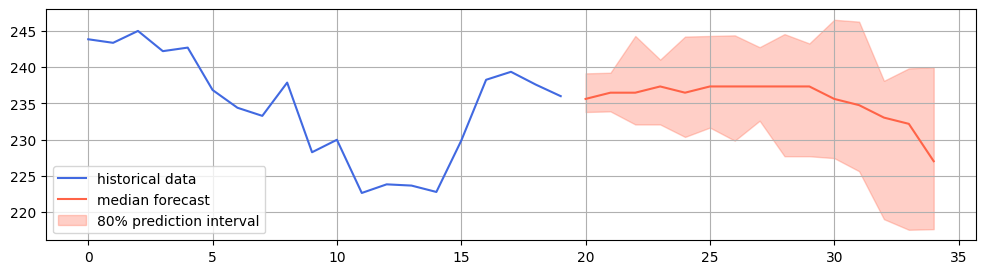

In [134]:
forecast_index = range(len(close), len(close) + 15)
low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

plt.figure(figsize=(12, 3))
plt.plot(close, color="royalblue", label="historical data")
plt.plot(forecast_index, median, color="tomato", label="median forecast")
plt.fill_between(forecast_index, low, high, color="tomato", alpha=0.3, label="80% prediction interval")
plt.legend()
plt.grid()
plt.show()

# Revenue

In [14]:
# set your query params
ticker = 'NVDA'     
period = 'quarterly'      
limit = 30

# create the URL
url = (
    f'https://api.financialdatasets.ai/financials/income-statements'
    f'?ticker={ticker}'
    f'&period={period}'
    f'&limit={limit}'
)

# make API request
response = requests.get(url, headers=headers)

# parse income_statements from the response
income_statements = response.json().get('income_statements')

In [25]:
revenue = [(items["fiscal_period"], items["revenue"]) for items in income_statements]
revenue.reverse()
len(revenue), revenue[0], revenue[-1]

(30, ('2018-Q4', 2911000000.0), ('2026-Q1', 44062000000.0))

# Revenue & Net Income

In [38]:
net_income = [(items["fiscal_period"], items["net_income"]) for items in income_statements]
net_income.reverse()
len(net_income), net_income[0], net_income[-1]

(30, ('2018-Q4', 1119000000.0), ('2026-Q1', 18775000000.0))

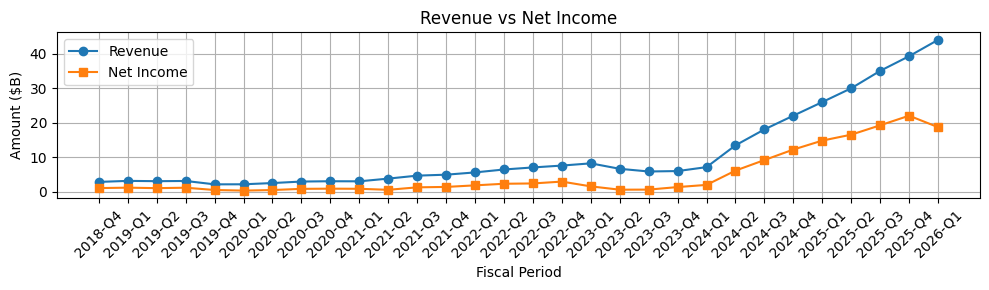

In [40]:
quarters = [q for q, _ in revenue]
revenue_vals = [v / 1e9 for _, v in revenue]
net_vals = [v / 1e9 for _, v in net_income]

plt.figure(figsize=(10, 3))
plt.plot(quarters, revenue_vals, label="Revenue", marker='o')
plt.plot(quarters, net_vals, label="Net Income", marker='s')
plt.title("Revenue vs Net Income")
plt.xlabel("Fiscal Period")
plt.ylabel("Amount ($B)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Leverage & Capital Efficiency

In [46]:
headers = {
    "X-API-KEY": API
}
# set your query params
ticker = 'NVDA'     
period = 'annual'      
limit = 30

# create the URL
url = (
    f'https://api.financialdatasets.ai/financials/balance-sheets'
    f'?ticker={ticker}'
    f'&period={period}'
    f'&limit={limit}'
)
# make API request
response = requests.get(url, headers=headers)

# parse balance_sheets from the response
balance_sheets = response.json().get('balance_sheets')

In [56]:
leverage = [(items["fiscal_period"], items["shareholders_equity"] / items["total_assets"] * 100) for items in balance_sheets[:-1]]
leverage.reverse()
print(len(leverage), leverage[0], leverage[-1])

debt_to_equity = [(items["fiscal_period"], items["total_liabilities"] / items["shareholders_equity"] * 100) for items in balance_sheets[:-1]]
debt_to_equity.reverse()
print(len(debt_to_equity), debt_to_equity[0], debt_to_equity[-1])


29 ('1996-FY', 18.76923076923077) ('2025-FY', 71.08090429297228)
29 ('1996-FY', 432.78688524590166) ('2025-FY', 40.68476054811098)


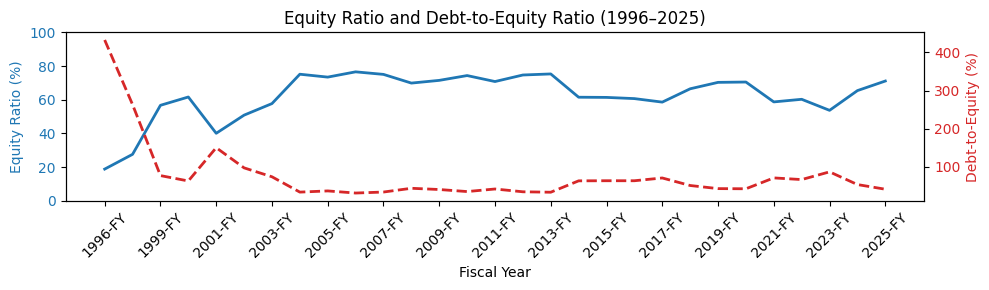

In [58]:
years = [item[0] for item in leverage]
equity_ratios = [item[1] for item in leverage]
debt_equity_ratios = [item[1] for item in debt_to_equity]

# 그래프
fig, ax1 = plt.subplots(figsize=(10, 3))

# Equity Ratio
ax1.set_xlabel("Fiscal Year")
ax1.set_ylabel("Equity Ratio (%)", color="tab:blue")
ax1.plot(years, equity_ratios, color="tab:blue", label="Equity Ratio", linewidth=2)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 100)
ax1.set_xticks(years[::2])
ax1.set_xticklabels(years[::2], rotation=45)

# Debt-to-Equity
ax2 = ax1.twinx()
ax2.set_ylabel("Debt-to-Equity (%)", color="tab:red")
ax2.plot(years, debt_equity_ratios, color="tab:red", label="Debt-to-Equity", linewidth=2, linestyle="--")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Equity Ratio and Debt-to-Equity Ratio (1996–2025)")
fig.tight_layout()
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.show()

# Cash Flow

In [59]:
# set your query params
ticker = 'NVDA'     # stock ticker
period = 'annual'   # possible values are 'annual', 'quarterly', or 'ttm'
limit = 30          # number of statements to return

# create the URL
url = (
    f'https://api.financialdatasets.ai/financials/cash-flow-statements'
    f'?ticker={ticker}'
    f'&period={period}'
    f'&limit={limit}'
)

# make API request
response = requests.get(url, headers=headers)

# parse cash_flow_statements from the response
cash_flow_statements = response.json().get('cash_flow_statements')

In [64]:
operation = [(items["fiscal_period"], items["net_cash_flow_from_operations"]) for items in cash_flow_statements]
operation.reverse()
print(len(operation), operation[0], operation[-1])

investment = [(items["fiscal_period"], items["net_cash_flow_from_investing"]) for items in cash_flow_statements]
investment.reverse()
print(len(investment), investment[0], investment[-1])

financing = [(items["fiscal_period"], items["net_cash_flow_from_financing"]) for items in cash_flow_statements]
financing.reverse()
print(len(financing), financing[0], financing[-1])


30 ('1995-FY', -6133000.0) ('2025-FY', 64089000000.0)
30 ('1995-FY', -5000.0) ('2025-FY', -20421000000.0)
30 ('1995-FY', 5455000.0) ('2025-FY', -42359000000.0)


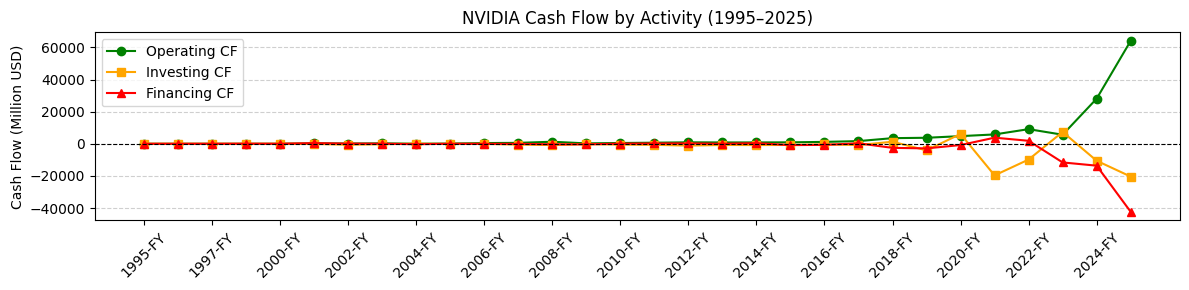

In [67]:
# 예시 데이터 (역순으로 이미 정렬됨)
years = [x[0] for x in operation]
operating_cf = [x[1] / 1e6 for x in operation]    # 백백만 달러
investing_cf = [x[1] / 1e6 for x in investment]
financing_cf = [x[1] / 1e6 for x in financing]

plt.figure(figsize=(12, 3))
plt.plot(years, operating_cf, label="Operating CF", color='green', marker='o')
plt.plot(years, investing_cf, label="Investing CF", color='orange', marker='s')
plt.plot(years, financing_cf, label="Financing CF", color='red', marker='^')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.xticks(years[::2], rotation=45)
plt.ylabel("Cash Flow (Million USD)")
plt.title("NVIDIA Cash Flow by Activity (1995–2025)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [101]:
# set your query params
ticker = 'NVDA'     # stock ticker
limit = 100         # number of trades to return

# create the URL
url = (
    f'https://api.financialdatasets.ai/insider-trades'
    f'?ticker={ticker}'
    f'&limit={limit}'
)

# make API request
response = requests.get(url, headers=headers)

# parse insider_trades from the response
insider_trades = response.json().get('insider_trades')

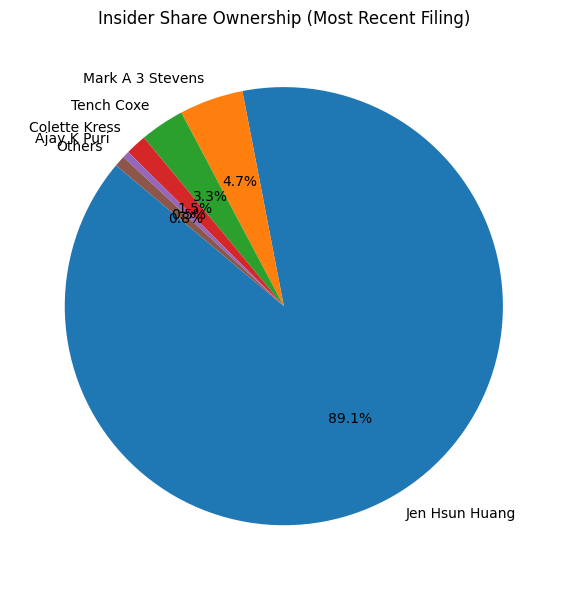

In [119]:
latest_holdings = defaultdict(lambda: {'filing_date': '', 'shares': 0})

for d in insider_trades:
    name = d['name']
    date = d['filing_date']
    shares = d.get('shares_owned_after_transaction', 0)

    # 최신 filing_date만 유지
    if latest_holdings[name]['filing_date'] < date:
        latest_holdings[name]['filing_date'] = date
        latest_holdings[name]['shares'] = shares
    elif latest_holdings[name]['filing_date'] == date:
        latest_holdings[name]['shares'] += shares  # 같은 날짜일 경우 누적

# 파이차트용 데이터 준비
labels = []
values = []
for name, data in latest_holdings.items():
    if data['shares'] > 0:
        labels.append(name)
        values.append(data['shares'])

# others로 묶기 (Top 5)
sorted_data = sorted(zip(labels, values), key=lambda x: x[1], reverse=True)
top_n = 5
top_labels = [x[0] for x in sorted_data[:top_n]]
top_values = [x[1] for x in sorted_data[:top_n]]
others_sum = sum(x[1] for x in sorted_data[top_n:])

if others_sum > 0:
    top_labels.append("Others")
    top_values.append(others_sum)

# 파이차트 그리기
plt.figure(figsize=(6, 6))
plt.pie(top_values, labels=top_labels, autopct="%1.1f%%", startangle=140)
plt.title("Insider Share Ownership (Most Recent Filing)")
plt.tight_layout()
plt.show()